In [2]:
import os

# Check if directory exists before creating it
if not os.path.exists("data"):
    os.mkdir("data")
else:
    print("Directory 'data' already exists")

Directory 'data' already exists


In [3]:
### TASK 1: Descriptive statistics for Block design scores of the participants

import pandas as pd

# Load the data with relative path
assessments = pd.read_excel("data/Assessments.xlsx")

score_col = "Block Design Score"

# Compute descriptive statistics
desc_table = assessments[score_col].describe(percentiles=[0.25, 0.5, 0.75]).to_frame().T

# Naming columns for better readability
desc_table = desc_table.rename(columns={
    "count": "Number of Participants (N)",
    "mean": "Mean (Average)",
    "std": "Standard Deviation",
    "min": "Minimum Score",
    "25%": "25th Percentile (Lower Quartile)",
    "50%": "50th Percentile (Median)",
    "75%": "75th Percentile (Upper Quartile)",
    "max": "Maximum Score"
})

# Rounding numbers for neat display
desc_table = desc_table.round(2)

# Display the result table
display(desc_table)


,Number of Participants (N),Mean (Average),Standard Deviation,Minimum Score,25th Percentile (Lower Quartile),50th Percentile (Median),75th Percentile (Upper Quartile),Maximum Score
Block Design Score,13.0,39.31,12.32,24.0,30.0,36.0,48.0,63.0


In [ ]:
## A descriptive analysis was conducted for participants’ Block Design scores. On average, participants scored 39.31 (SD = 12.32, N = 13), with scores ranging from 24 to 63. The standard deviation of 12.32 indicates that participants’ scores varied moderately around the mean, reflecting individual differences in visuospatial reasoning ability. The sample size (N = 13) represents the total number of participants included in the analysis. The 25th percentile (lower quartile) was 30.00, the median (50th percentile) was 36.00, and the 75th percentile (upper quartile) was 48.00, suggesting a moderate spread of cognitive performance across the group.

In [4]:
### TASK 2: Total recipe completion time for each participant

import pandas as pd
import glob, os

# find all participant CSV files in the data folder
participant_files = glob.glob("data/C*_SimpleStew_CompletedStepsData.csv")

# store total completion times( # last step time  = total completion time)
total_times = []

for file in sorted(participant_files):
    df = pd.read_csv(file)
    participant_id = os.path.basename(file).split("_")[0]   
    total_completion_time = df["Session Time"].max()        
    total_times.append({
        "Participant ID": participant_id,
        "Total Completion Time (seconds)": (total_completion_time)
    })

# create the results table
total_completion_table = pd.DataFrame(total_times)

# display the table neatly
display(total_completion_table)



,Participant ID,Total Completion Time (seconds)
0,C008,352.999298
1,C009,452.493500
2,C013,451.592560
3,C016,198.272446
4,C017,403.606689
5,C021,580.019897
6,C024,200.094406
7,C025,430.629974
8,C032,251.382736
9,C033,476.875946


In [5]:
### TASK 3 Spearman correlation analysis,correlation coefficient and p-value.


from scipy import stats

# column names
score_col = "Block Design Score"           # Has to match the name from the files
participant_col_excel = "TOPF\nSubject ID"  
participant_col_csv = "Participant ID"      

# merge both tables using an inner join
merged_data = pd.merge(
    assessments,
    total_completion_table,
    left_on=participant_col_excel,
    right_on=participant_col_csv,
    how="inner"
)

# compute Spearman correlation
rho, p_value = stats.spearmanr(
    merged_data[score_col],
    merged_data["Total Completion Time (seconds)"]
)

# create results table
corr_table = pd.DataFrame({
    "Correlation Type": ["Spearman (ρ)"],
    "Correlation Coefficient (ρ)": [round(rho, 3)],
    "p-value": [round(p_value, 4)],
    "N (Number of Participants)": [len(merged_data)]
})

display(corr_table)


,Correlation Type,Correlation Coefficient (ρ),p-value,N (Number of Participants)
0,Spearman (ρ),-0.397,0.1796,13


In [ ]:
### A Spearman rank-order correlation was conducted to examine the relationship between participants’ visuospatial reasoning ability, Block Design scores and total recipe completion time. The analysis revealed a moderate negative correlation, ρ = −0.40, p = .18 (N = 13). Although the relationship was not statistically significant at the .05 level, the negative coefficient suggests that participants with higher Block Design scores tended to complete the recipe in less time, indicating a potential trend where greater visuospatial ability may be associated with faster task performance. The p-value of .18 indicates that this result could have occurred by chance, so the relationship should be interpreted with caution and may require a larger sample to confirm its reliability.

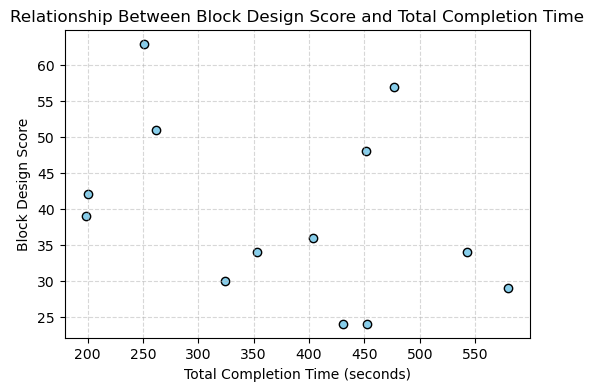

In [14]:
## TASK 4 scatter plot comparing total completion times and Block Design scores.

import matplotlib.pyplot as plt


%matplotlib inline

plt.figure(figsize=(6, 4))
plt.scatter(
    merged_data["Total Completion Time (seconds)"],
    merged_data["Block Design Score"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Relationship Between Block Design Score and Total Completion Time")
plt.xlabel("Total Completion Time (seconds)")
plt.ylabel("Block Design Score")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()




--- Linear Regression Results ---
Slope: -0.0357
Intercept: 52.8309
Linear Equation:  y = -0.0357 * x + 52.8309



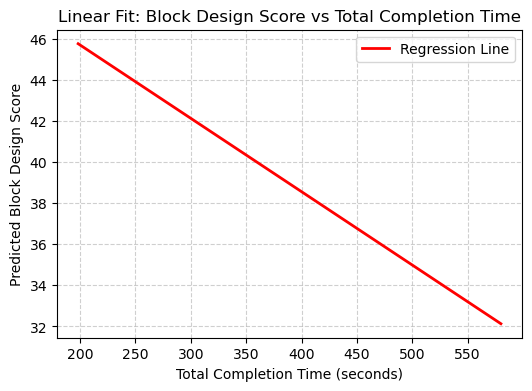

In [19]:
## Task 5 linear fit for the data (total completion times and Block Design scores

import numpy as np
import matplotlib.pyplot as plt

# Define variables
x = merged_data["Total Completion Time (seconds)"]
y = merged_data["Block Design Score"]

# Compute linear fit (y = slope * x + intercept)
slope, intercept = np.polyfit(x, y, 1)

print("--- Linear Regression Results ---")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Linear Equation:  y = {slope:.4f} * x + {intercept:.4f}\n")

# --- Visualization (Regression line ) ---
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(6, 4))
plt.plot(x_fit, y_fit, color="red", linewidth=2, label="Regression Line")

plt.title("Linear Fit: Block Design Score vs Total Completion Time")
plt.xlabel("Total Completion Time (seconds)")
plt.ylabel("Predicted Block Design Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()



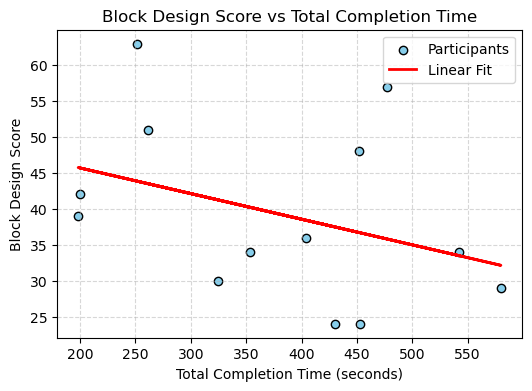

In [17]:
## TASK 6: Draw an overlapping linear line on the scatter plot.

import matplotlib.pyplot as plt
import numpy as np

# x = total completion times, y = block design scores
x = merged_data["Total Completion Time (seconds)"]
y = merged_data["Block Design Score"]

# use the same linear fit coefficients from Task 5
slope, intercept = np.polyfit(x, y, 1)

# predicted y values for the line
y_pred = slope * x + intercept

# create the scatter plot and linear line together
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color="skyblue", edgecolor="black", label="Participants")
plt.plot(x, y_pred, color="red", linewidth=2, label="Linear Fit")

plt.title("Block Design Score vs Total Completion Time")
plt.xlabel("Total Completion Time (seconds)")
plt.ylabel("Block Design Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [21]:
## Task 7: Explain the implications

import textwrap

# Linear regression results 
slope = -0.0357
intercept = 52.8309

# APA-style implications paragraph
implications_text = (
    "A simple linear regression was conducted to examine the relationship between "
    "Block Design scores and total completion times. Block Design score was entered "
    "as the dependent variable (Y-axis) and total completion time (in seconds) as the "
    "independent variable (X-axis). The regression equation was: "
    f"Y = {slope:.4f}X + {intercept:.4f}. The analysis revealed a negative linear "
    "relationship between completion time and Block Design performance, suggesting "
    "that participants who took longer to complete the task tended to have lower "
    "visuospatial reasoning scores. The negative slope indicates an inverse trend, "
    "whereas the variability around the regression line suggests that this relationship "
    "was modest, reflecting potential influence from additional cognitive or behavioral factors."
)

# Print neatly formatted output
print("\nIMPLICATIONS\n")
print(textwrap.fill(implications_text, width=90))



IMPLICATIONS

A simple linear regression was conducted to examine the relationship between Block Design
scores and total completion times. Block Design score was entered as the dependent
variable (Y-axis) and total completion time (in seconds) as the independent variable
(X-axis). The regression equation was: Y = -0.0357X + 52.8309. The analysis revealed a
negative linear relationship between completion time and Block Design performance,
suggesting that participants who took longer to complete the task tended to have lower
visuospatial reasoning scores. The negative slope indicates an inverse trend, whereas the
variability around the regression line suggests that this relationship was modest,
reflecting potential influence from additional cognitive or behavioral factors.


In [23]:
## Task 8: Compute a quantitative measure (Pacing Consistency Index)

import pandas as pd, numpy as np, glob, os

# Find all participant CSV files in the data folder
participant_files = glob.glob("data/C*_SimpleStew_CompletedStepsData.csv")

# Store PCI results
pci_results = []

# --- Print formula (for clarity in report) ---
from IPython.display import Markdown, display
display(Markdown("### Formula for PCI"))
display(Markdown(r"**PCI** = $\frac{1}{1 + CV}$, &nbsp;&nbsp; where &nbsp;&nbsp; **CV** = $\frac{SD_{interval}}{Mean_{interval}}$"))

# Compute PCI for each participant
for file in sorted(participant_files):
    df = pd.read_csv(file)
    pid = os.path.basename(file).split("_")[0]  # e.g., "C008"
    
    # Sort times
    times = np.sort(df["Session Time"].astype(float).values)
    
    if len(times) < 2:
        pci_results.append({
            "Participant ID": pid,
            "Mean Interval": np.nan,
            "SD Interval": np.nan,
            "Coefficient of Variation (CV)": np.nan,
            "Pacing Consistency Index (PCI)": np.nan
        })
        continue

    # Compute step intervals
    intervals = np.diff(times)
    
    # Compute descriptive stats
    mean_interval = np.mean(intervals)
    sd_interval = np.std(intervals, ddof=1)
    cv = sd_interval / mean_interval if mean_interval > 0 else np.nan
    
    # Compute PCI
    pci = 1 / (1 + cv) if cv == cv else np.nan

    # Store results
    pci_results.append({
        "Participant ID": pid,
        "Mean Interval": round(mean_interval, 3),
        "SD Interval": round(sd_interval, 3),
        "Coefficient of Variation (CV)": round(cv, 3),
        "Pacing Consistency Index (PCI)": round(pci, 3)
    })

# Create DataFrame
pci_table = pd.DataFrame(pci_results)

# Highlight PCI column for readability
def highlight_pci(val, col_name):
    if col_name == "Pacing Consistency Index (PCI)":
        return 'background-color: #f9f2d0; font-weight: bold; color: #000'
    return ''

styled_table = pci_table.style.apply(
    lambda x: [highlight_pci(v, x.name) for v in x],
    axis=0
)

display(styled_table)





### Formula for PCI

**PCI** = $\frac{1}{1 + CV}$, &nbsp;&nbsp; where &nbsp;&nbsp; **CV** = $\frac{SD_{interval}}{Mean_{interval}}$

,Participant ID,Mean Interval,SD Interval,Coefficient of Variation (CV),Pacing Consistency Index (PCI)
0,C008,9.796000,11.239000,1.147000,0.466000
1,C009,11.836000,9.688000,0.819000,0.550000
2,C013,13.703000,22.890000,1.670000,0.374000
3,C016,5.696000,6.860000,1.204000,0.454000
4,C017,9.537000,14.207000,1.490000,0.402000
5,C021,13.300000,21.887000,1.646000,0.378000
6,C024,5.707000,7.543000,1.322000,0.431000
7,C025,11.084000,16.201000,1.462000,0.406000
8,C032,7.002000,11.844000,1.691000,0.372000
9,C033,11.480000,14.430000,1.257000,0.443000


--- Spearman Correlation: PCI vs Block Design Score ---
ρ (rho): -0.413
p-value: 0.1605
N: 13

--- Linear Regression (for visualization) ---
Slope: -113.0680
Intercept: 87.4921
Equation:  y = -113.0680 * x + 87.4921



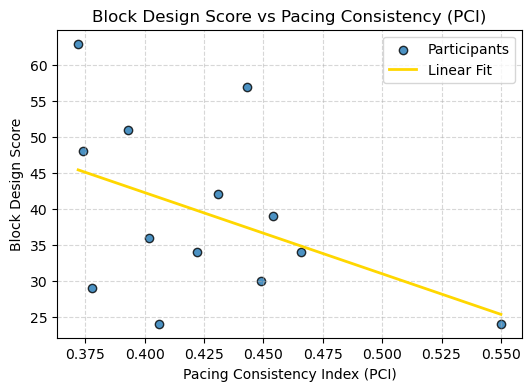

In [26]:
## Task 9 Spearman Correlation and Linear Regression for  PCI vs Block Design Score ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1) Merge existing tables by Participant ID using inner join
merged_with_pci = pd.merge(
    merged_data,
    pci_table,
    on="Participant ID",
    how="inner"
)

# 2) Spearman correlation: PCI vs Block Design Score
x = merged_with_pci["Pacing Consistency Index (PCI)"].astype(float)
y = merged_with_pci["Block Design Score"].astype(float)

valid = merged_with_pci[["Pacing Consistency Index (PCI)", "Block Design Score"]].dropna()
xv = valid["Pacing Consistency Index (PCI)"].values
yv = valid["Block Design Score"].values

rho, p = stats.spearmanr(xv, yv)
print("--- Spearman Correlation: PCI vs Block Design Score ---")
print(f"ρ (rho): {rho:.3f}")
print(f"p-value: {p:.4f}")
print(f"N: {len(valid)}\n")

# 3) Linear fit (for visualization)
slope, intercept = np.polyfit(xv, yv, 1)
print("--- Linear Regression (for visualization) ---")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Equation:  y = {slope:.4f} * x + {intercept:.4f}\n")

# 4) Scatter + linear fit (with yellow line)
plt.figure(figsize=(6,4))
plt.scatter(xv, yv, edgecolor="black", alpha=0.8, label="Participants")

x_fit = np.linspace(xv.min(), xv.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color="gold", linewidth=2, label="Linear Fit")

plt.title("Block Design Score vs Pacing Consistency (PCI)")
plt.xlabel("Pacing Consistency Index (PCI)")
plt.ylabel("Block Design Score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()
